# 📉 Customer Churn Prediction — Exploratory Data Analysis
**Dataset:** Telco Customer Churn (Kaggle)  
**Author:** Sandeep Kumar | LPU  
**Purpose:** ShyftLabs Placement Portfolio — Data Science Track

---
## Notebook Structure
1. Environment Setup & Data Loading
2. Dataset Overview & Schema Audit
3. Missing Value & Data Quality Analysis
4. Target Variable Distribution (Churn)
5. Numerical Feature Analysis
6. Categorical Feature Analysis
7. Correlation & Feature Relationships
8. EDA Summary & Feature Engineering Recommendations

## Section 1 — Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

PALETTE = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED']
os.makedirs('../reports/figures', exist_ok=True)
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# Load dataset
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Section 2 — Dataset Overview & Schema Audit

In [3]:
print('=== DTYPES ===')
print(df.dtypes)
print(f'\nRows: {df.shape[0]:,} | Columns: {df.shape[1]}')

=== DTYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Rows: 7,043 | Columns: 21


In [4]:
# Column-level audit
audit = pd.DataFrame({
    'dtype'      : df.dtypes,
    'nunique'    : df.nunique(),
    'null_count' : df.isnull().sum(),
    'null_pct'   : (df.isnull().mean() * 100).round(2),
    'sample_val' : df.iloc[0]
})
audit

,dtype,nunique,null_count,null_pct,sample_val
customerID,object,7043,0,0.00,7590-VHVEG
gender,object,2,0,0.00,Female
SeniorCitizen,int64,2,0,0.00,0
Partner,object,2,0,0.00,Yes
Dependents,object,2,0,0.00,No
tenure,int64,73,0,0.00,1
PhoneService,object,2,0,0.00,No
MultipleLines,object,3,0,0.00,No phone service
InternetService,object,3,0,0.00,DSL
OnlineSecurity,object,3,0,0.00,No


## Section 3 — Missing Value & Data Quality Analysis

In [5]:
# TotalCharges is object — needs conversion
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing = df.isnull().sum()
missing = missing[missing > 0]
print('Missing values after TotalCharges conversion:')
print(missing)

# These are new customers with tenure=0, safe to fill with 0
df['TotalCharges'].fillna(0, inplace=True)
print(f'\nRemaining nulls: {df.isnull().sum().sum()}')

Missing values after TotalCharges conversion:
TotalCharges    11
dtype: int64

Remaining nulls: 0


In [6]:
# Drop customerID — not a feature
df.drop(columns=['customerID'], inplace=True)

# Encode target
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
print('Target encoding done')
print(df['Churn_binary'].value_counts())

Target encoding done
Churn_binary
0    5174
1    1869
Name: count, dtype: int64


## Section 4 — Target Variable Distribution (Churn)

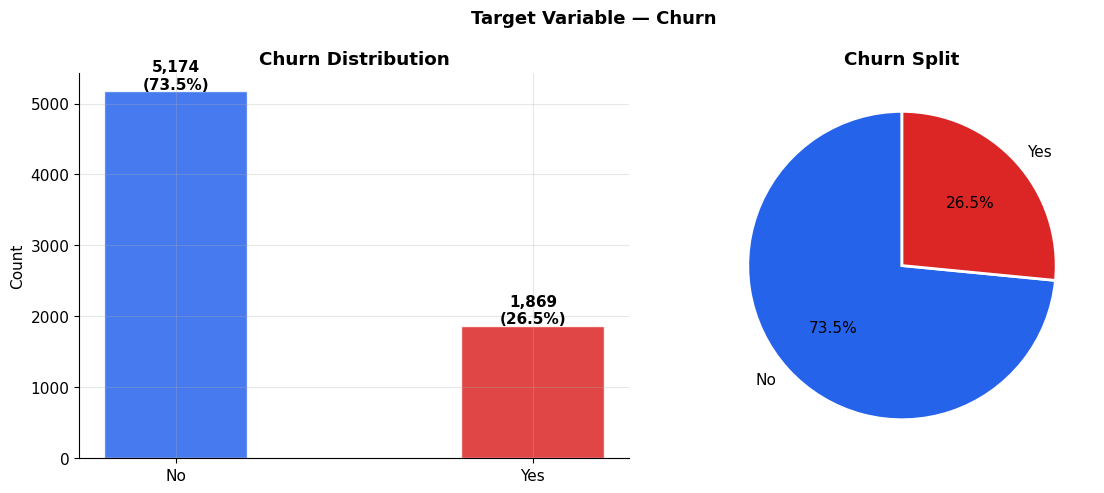


Class imbalance ratio: 2.77:1 (No:Yes)
→ Will use SMOTE to handle class imbalance during model training


In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=[PALETTE[0], PALETTE[1]], alpha=0.85, edgecolor='white', width=0.4)
for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            colors=[PALETTE[0], PALETTE[1]],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Split', fontweight='bold')

plt.suptitle('Target Variable — Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClass imbalance ratio: {churn_counts[0]/churn_counts[1]:.2f}:1 (No:Yes)')
print('→ Will use SMOTE to handle class imbalance during model training')

## Section 5 — Numerical Feature Analysis

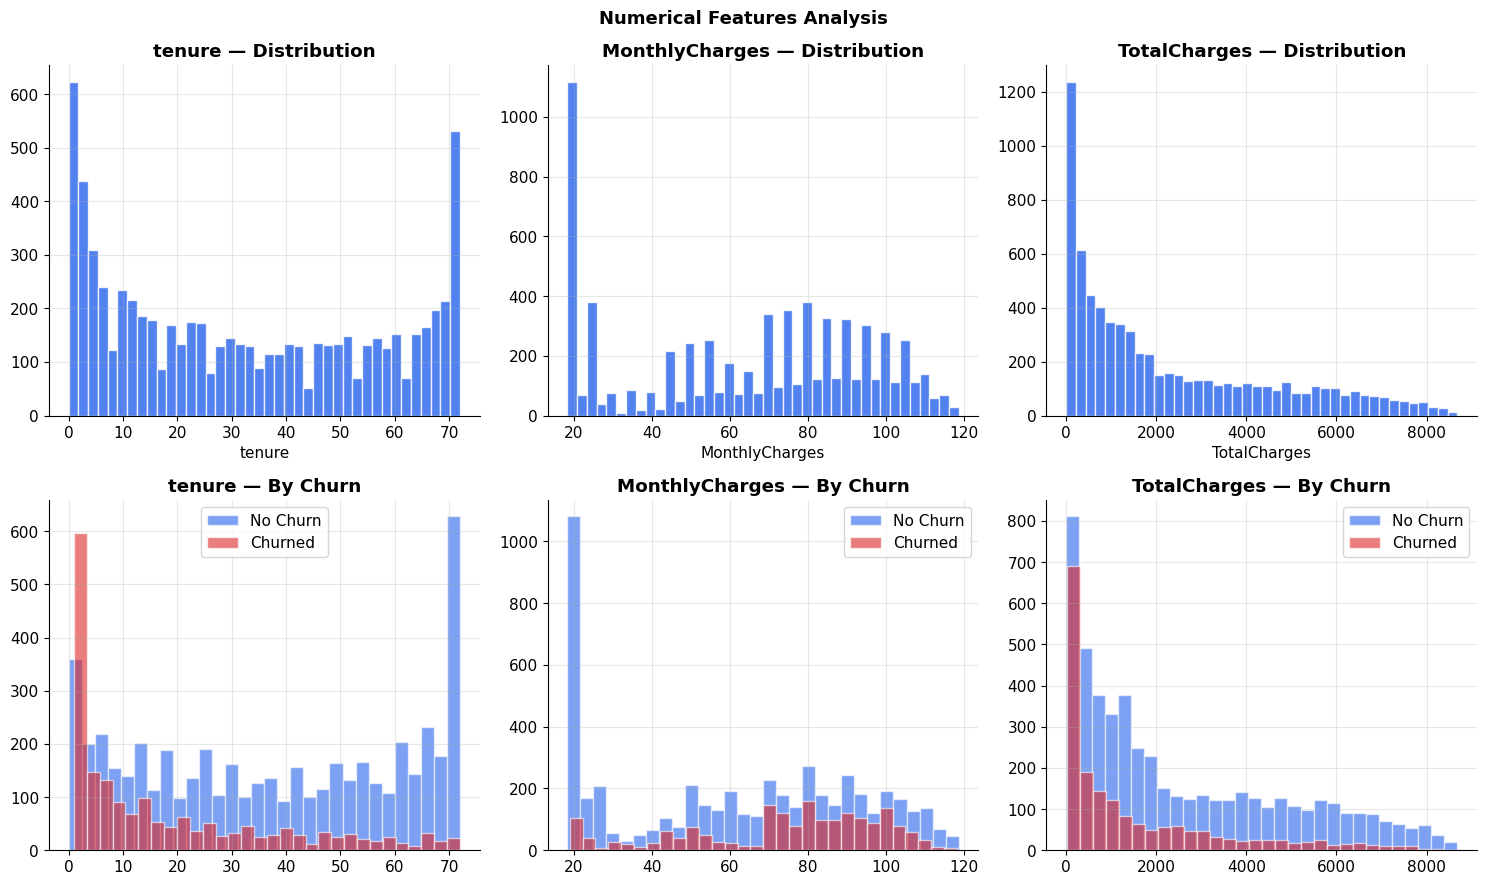

=== Numerical Stats by Churn ===
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80


In [8]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, col in enumerate(num_cols):
    # Distribution
    axes[0][i].hist(df[col], bins=40, color=PALETTE[0], alpha=0.8, edgecolor='white')
    axes[0][i].set_title(f'{col} — Distribution', fontweight='bold')
    axes[0][i].set_xlabel(col)

    # By churn
    for churn_val, color, label in zip([0,1], [PALETTE[0], PALETTE[1]], ['No Churn','Churned']):
        subset = df[df['Churn_binary'] == churn_val][col]
        axes[1][i].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[1][i].set_title(f'{col} — By Churn', fontweight='bold')
    axes[1][i].legend()

plt.suptitle('Numerical Features Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/numerical_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Numerical Stats by Churn ===')
print(df.groupby('Churn')[num_cols].mean().round(2))

## Section 6 — Categorical Feature Analysis

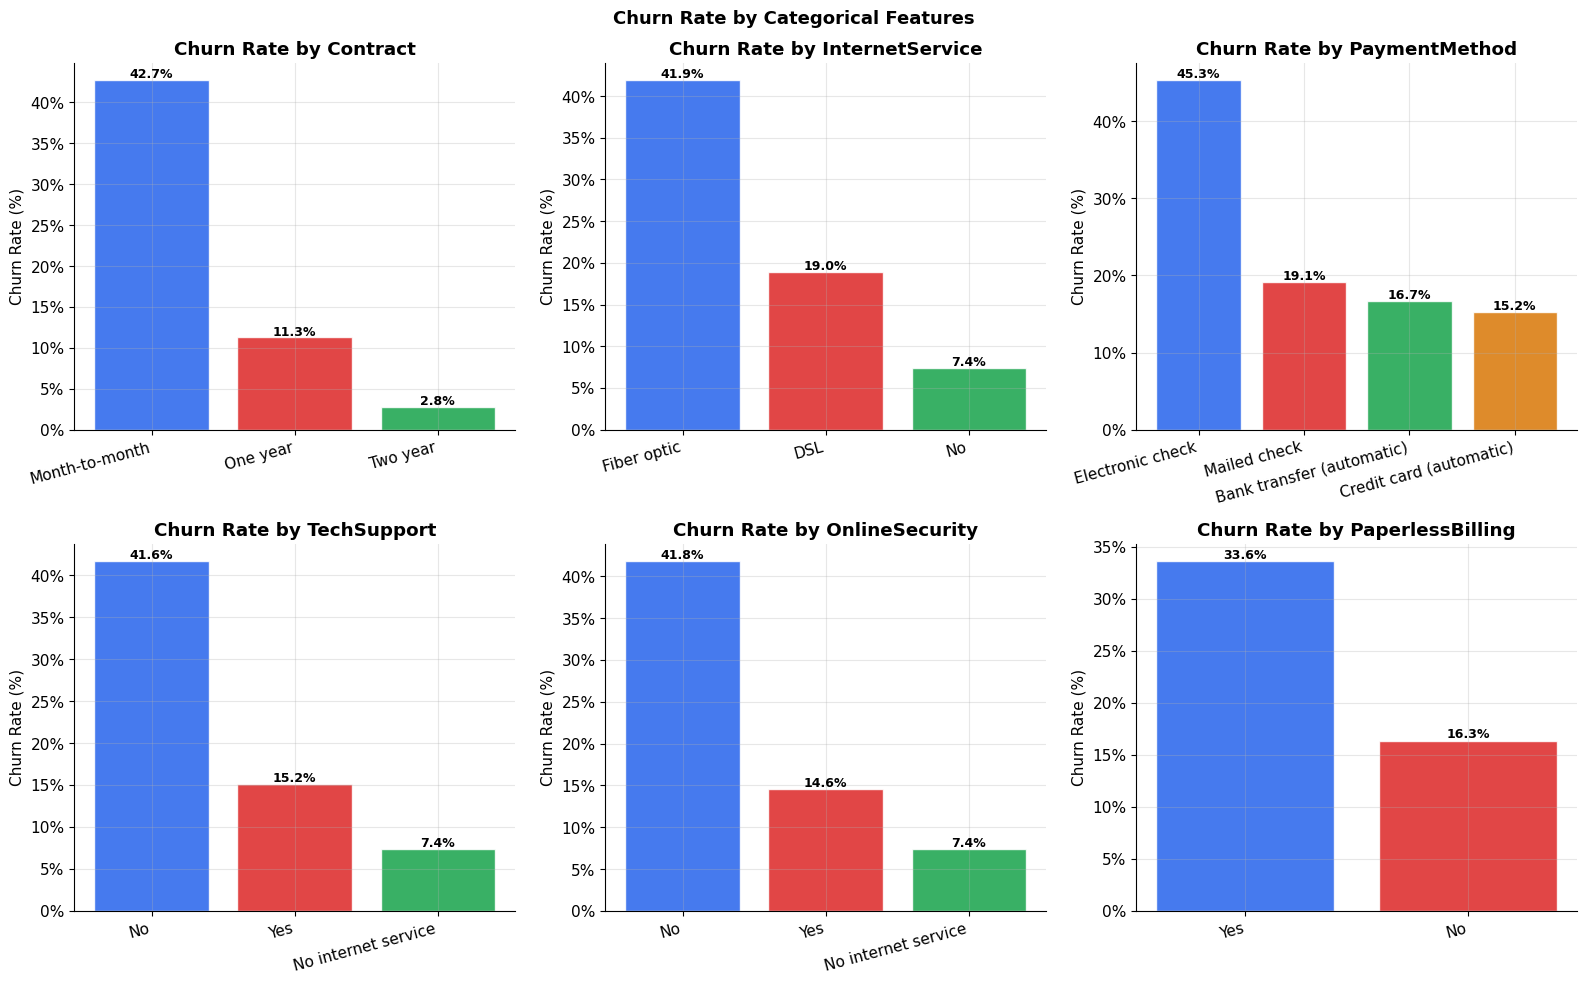

In [9]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn_binary'].mean().sort_values(ascending=False)
    bars = axes[i].bar(churn_rate.index, churn_rate.values * 100,
                       color=PALETTE[:len(churn_rate)], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15, ha='right')
    axes[i].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))

plt.suptitle('Churn Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Correlation & Feature Relationships

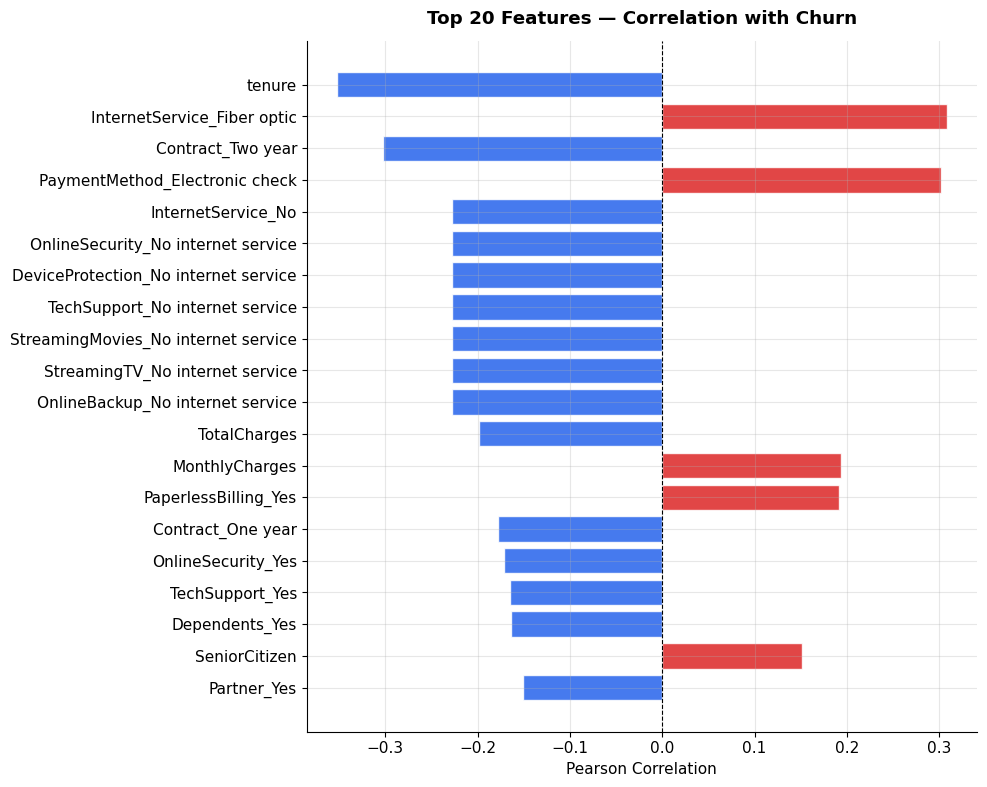

Top 10 positive correlators with Churn:
tenure                                 -0.35
InternetService_Fiber optic             0.31
Contract_Two year                      -0.30
PaymentMethod_Electronic check          0.30
InternetService_No                     -0.23
OnlineSecurity_No internet service     -0.23
DeviceProtection_No internet service   -0.23
TechSupport_No internet service        -0.23
StreamingMovies_No internet service    -0.23
StreamingTV_No internet service        -0.23
Name: Churn_binary, dtype: float64

Top 10 negative correlators with Churn:
PaymentMethod_Credit card (automatic)   -0.13
PaymentMethod_Mailed check              -0.09
OnlineBackup_Yes                        -0.08
DeviceProtection_Yes                    -0.07
StreamingTV_Yes                          0.06
StreamingMovies_Yes                      0.06
MultipleLines_Yes                        0.04
MultipleLines_No phone service          -0.01
PhoneService_Yes                         0.01
gender_Male         

In [10]:
# Encode all categoricals for correlation
df_encoded = pd.get_dummies(df.drop(columns=['Churn']), drop_first=True)

# Correlation with target
corr_target = df_encoded.corr()['Churn_binary'].drop('Churn_binary').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [PALETTE[1] if v > 0 else PALETTE[0] for v in corr_target.head(20).values]
ax.barh(corr_target.head(20).index[::-1], corr_target.head(20).values[::-1],
        color=colors[::-1], alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top 20 Features — Correlation with Churn', fontweight='bold', pad=12)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('../reports/figures/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 positive correlators with Churn:')
print(corr_target.head(10))
print('\nTop 10 negative correlators with Churn:')
print(corr_target.tail(10))

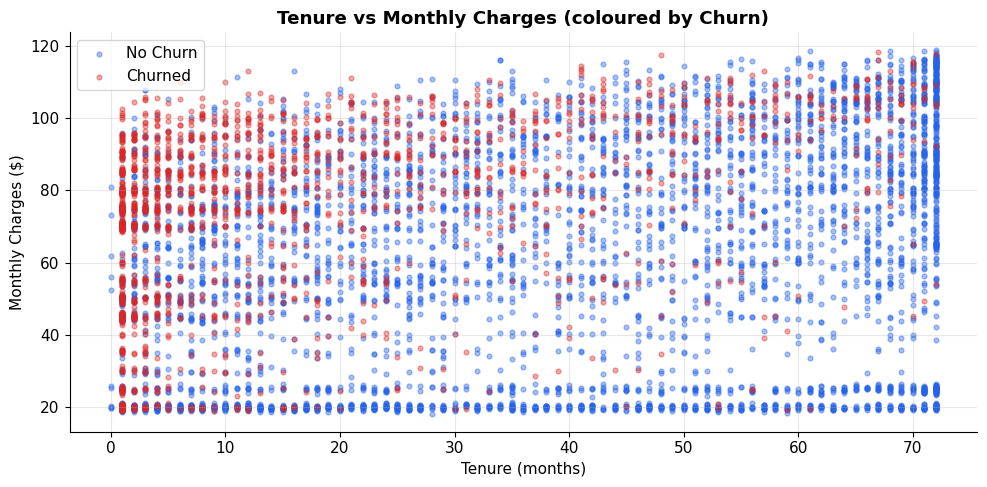

In [11]:
# Tenure vs MonthlyCharges scatter coloured by churn
fig, ax = plt.subplots(figsize=(10, 5))
for churn_val, color, label in zip([0,1], [PALETTE[0], PALETTE[1]], ['No Churn','Churned']):
    subset = df[df['Churn_binary'] == churn_val]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'],
               c=color, alpha=0.4, s=12, label=label)
ax.set_title('Tenure vs Monthly Charges (coloured by Churn)', fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/tenure_vs_charges.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8 — EDA Summary & Feature Engineering Recommendations

In [12]:
summary = """
╔══════════════════════════════════════════════════════════════════════╗
║           EDA SUMMARY — TELCO CUSTOMER CHURN                         ║
╠══════════════════════════════════════════════════════════════════════╣
║  Dataset     : 7,043 rows × 20 features                             ║
║  Target      : Churn (Yes/No) → 26.5% churn rate                   ║
║  Imbalance   : ~2.7:1 (No:Yes) → SMOTE required                    ║
╠══════════════════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                                        ║
║  1. Month-to-month contracts have 3x higher churn than 2-year       ║
║  2. Customers with Fiber optic internet churn more (41.9%)          ║
║  3. No TechSupport / OnlineSecurity → significantly higher churn    ║
║  4. High MonthlyCharges + low tenure = highest churn risk           ║
║  5. Electronic check payment method has highest churn rate          ║
║  6. Tenure is the strongest negative predictor of churn             ║
╠══════════════════════════════════════════════════════════════════════╣
║  FEATURE ENGINEERING PLAN (for notebook 02)                         ║
║  • tenure_group: bin tenure into 0-12, 13-24, 25-48, 49-72 months  ║
║  • charges_per_month: TotalCharges / (tenure + 1)                   ║
║  • service_count: count of active add-on services                   ║
║  • is_new_customer: tenure <= 6 months flag                         ║
║  • Label encode binary cols, one-hot multi-class cols               ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════════╗
║           EDA SUMMARY — TELCO CUSTOMER CHURN                         ║
╠══════════════════════════════════════════════════════════════════════╣
║  Dataset     : 7,043 rows × 20 features                             ║
║  Target      : Churn (Yes/No) → 26.5% churn rate                   ║
║  Imbalance   : ~2.7:1 (No:Yes) → SMOTE required                    ║
╠══════════════════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                                        ║
║  1. Month-to-month contracts have 3x higher churn than 2-year       ║
║  2. Customers with Fiber optic internet churn more (41.9%)          ║
║  3. No TechSupport / OnlineSecurity → significantly higher churn    ║
║  4. High MonthlyCharges + low tenure = highest churn risk           ║
║  5. Electronic check payment method has highest churn rate          ║
║  6. Tenure is the strongest negative predictor of churn   